
Contour 0:
  line: (150, 0) -> (150, 1466)
  line: (150, 1466) -> (700, 1466)
  quadratic: (700, 1466) -> (868, 1466) -> (969.5, 1421.5)
  quadratic: (969.5, 1421.5) -> (1071, 1377) -> (1128.5, 1284.5)
  quadratic: (1128.5, 1284.5) -> (1186, 1192) -> (1186, 1091)
  quadratic: (1186, 1091) -> (1186, 997) -> (1135.0, 914.0)
  quadratic: (1135.0, 914.0) -> (1084, 831) -> (981, 780)
  quadratic: (981, 780) -> (1114, 741) -> (1185.5, 647.0)
  quadratic: (1185.5, 647.0) -> (1257, 553) -> (1257, 425)
  quadratic: (1257, 425) -> (1257, 322) -> (1213.5, 233.5)
  quadratic: (1213.5, 233.5) -> (1170, 145) -> (1106.0, 97.0)
  quadratic: (1106.0, 97.0) -> (1042, 49) -> (945.5, 24.5)
  quadratic: (945.5, 24.5) -> (849, 0) -> (709, 0)
  line: (709, 0) -> (150, 0)

Contour 1:
  line: (344, 850) -> (661, 850)
  quadratic: (661, 850) -> (790, 850) -> (846, 867)
  quadratic: (846, 867) -> (920, 889) -> (957.5, 940.0)
  quadratic: (957.5, 940.0) -> (995, 991) -> (995, 1068)
  quadratic: (995, 1068) -> (9

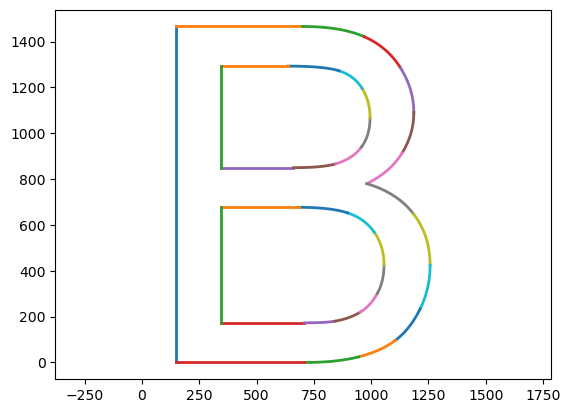

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from fontTools.ttLib import TTFont
from fontTools.pens.basePen import BasePen

class BezierExtractorPen(BasePen):
    def __init__(self, glyphSet):
        super().__init__(glyphSet)
        self.contours = []
        self.current_contour = []
        self.current_point = None
        self.start_point = None

    def _moveTo(self, p0):
        if self.current_contour:
            self.contours.append(self.current_contour)
        self.current_contour = []
        self.current_point = p0
        self.start_point = p0

    def _lineTo(self, p1):
        self.current_contour.append(("line", self.current_point, p1))
        self.current_point = p1

    def _qCurveToOne(self, p1, p2):
        self.current_contour.append(("quadratic", self.current_point, p1, p2))
        self.current_point = p2

    def _curveToOne(self, p1, p2, p3):
        self.current_contour.append(("cubic", self.current_point, p1, p2, p3))
        self.current_point = p3

    def _closePath(self):
        if self.current_point != self.start_point:
            self.current_contour.append(("line", self.current_point, self.start_point))
        self.contours.append(self.current_contour)
        self.current_contour = []


def bezier_quad(P0, P1, P2, t):
    return (1 - t)**2 * P0 + 2*(1 - t)*t * P1 + t**2 * P2

def bezier_cubic(P0, P1, P2, P3, t):
    return ((1 - t)**3 * P0 +
            3*(1 - t)**2 * t * P1 +
            3*(1 - t) * t**2 * P2 +
            t**3 * P3)

def print_structure(contours):
    for i, contour in enumerate(contours):
        print(f"\nContour {i}:")
        for seg in contour:
            if seg[0] == "line":
                _, P0, P1 = seg
                print(f"  line: {P0} -> {P1}")

            elif seg[0] == "quadratic":
                _, P0, P1, P2 = seg
                print(f"  quadratic: {P0} -> {P1} -> {P2}")

            elif seg[0] == "cubic":
                _, P0, P1, P2, P3 = seg
                print(f"  cubic: {P0} -> {P1} -> {P2} -> {P3}")

def draw_colored(contours):
    color_idx = 0

    for contour in contours:
        for seg in contour:
            t_values = np.linspace(0, 1, 80)

            if seg[0] == "line":
                _, P0, P1 = seg
                pts = np.array([P0, P1])

            elif seg[0] == "quadratic":
                _, P0, P1, P2 = seg
                pts = np.array([
                    bezier_quad(np.array(P0), np.array(P1), np.array(P2), t)
                    for t in t_values
                ])

            elif seg[0] == "cubic":
                _, P0, P1, P2, P3 = seg
                pts = np.array([
                    bezier_cubic(np.array(P0), np.array(P1), np.array(P2), np.array(P3), t)
                    for t in t_values
                ])
            else:
                continue

            plt.plot(pts[:, 0], pts[:, 1], linewidth=2)
            color_idx += 1
            
    plt.axis('equal')
    plt.show()

def main():
    font = TTFont("arial.ttf")
    glyphSet = font.getGlyphSet()

    glyph_name = "B"
    glyph = glyphSet[glyph_name]

    pen = BezierExtractorPen(glyphSet)
    glyph.draw(pen)
    print_structure(pen.contours)
    draw_colored(pen.contours)


if __name__ == "__main__":
    main()